# Markov chains for sequences

The simplest sequence model - a Markov chain, where the next symbol depends only on the current one - fit to real text, used to generate new sequences, and analyzed for its stationary distribution (long-run behavior). You'll also see when the first-order assumption is too weak and how order and data interact.


## The Markov property and the transition matrix

A sequence $X_0,X_1,\dots$ on a finite state space is a Markov chain if the future depends on the past
only through the present: $P(X_{t+1}=j\mid X_t=i, X_{t-1},\dots)=P(X_{t+1}=j\mid X_t=i)=P_{ij}$. The
transition matrix $P$ is row-stochastic ($P_{ij}\ge0$, $\sum_j P_{ij}=1$), and $n$-step transitions are
$P^n$. A distribution $\pi$ (a row vector) is stationary if $\pi P=\pi$.

Definition (irreducible, aperiodic). The chain is irreducible if every state reaches every other, and
aperiodic if the gcd of return times to a state is one. These two conditions rule out the pathologies
below.

## Convergence to the stationary distribution

Theorem (Perron-Frobenius / fundamental theorem of Markov chains). An irreducible, aperiodic finite chain
has a unique stationary distribution $\pi$ with $\pi_i>0$ for all $i$, and from any start the distribution
converges to it: $P(X_n=\cdot)\to\pi$, equivalently $P^n\to\mathbf 1\pi$.

Proof idea. $P$ has the eigenvalue $1$ with the all-ones right eigenvector and the left eigenvector $\pi$.
Perron-Frobenius says that for an irreducible aperiodic stochastic matrix, $1$ is a simple eigenvalue and
every other eigenvalue has modulus strictly less than one. Writing $P^n$ in its spectral decomposition,
all terms except the $\pi$ term decay, so $P^n\to\mathbf 1\pi$. $\quad\blacksquare$

Theorem (geometric convergence rate). The distance to stationarity decays geometrically at a rate set by
the spectral gap: $\|P(X_n=\cdot)-\pi\|_{TV} = O(|\lambda_2|^n)$, where $\lambda_2$ is the second-largest
eigenvalue modulus. The closer $|\lambda_2|$ is to one, the slower the mixing.

PageRank is exactly this $\pi$ for the (damped) web-link chain, computed by the power iteration
$\pi^{(n+1)}=\pi^{(n)}P$, whose convergence rate is the spectral gap above.

Counterexample (periodicity destroys convergence). The two-state chain that always switches,
$P=\begin{psmallmatrix}0&1\\1&0\end{psmallmatrix}$, is irreducible but periodic with period two. Its
distribution oscillates forever and never converges, even though a unique stationary distribution
$(\tfrac12,\tfrac12)$ exists. Reducible chains fail differently: they can have many stationary
distributions. We contrast a mixing chain with a periodic one below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, re
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import MarkovChainDistribution, MarkovChainEstimator, CategoricalEstimator
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)

# character sequences from a word list: each word is a sequence of letters
words = [w.lower() for w in open(os.path.join('../../data', 'dict', 'words')).read().split()
         if w.isalpha() and 3 <= len(w) <= 10]
rng.shuffle(words)
seqs = [list(w) for w in words[:8000]]
print('%d words; example sequences: %s' % (len(seqs), [''.join(s) for s in seqs[:5]]))

8000 words; example sequences: ['peridial', 'laine', 'bodo', 'kyat', 'cresamine']


## 1. Fit a first-order chain

A Markov chain over an alphabet is an initial distribution (first letter) plus a transition matrix $P(\text{next}\mid\text{current})$, with a length model for when sequences stop. Maximum likelihood is just normalized bigram counts. We fit one and read off the most likely successors of a few letters - the model has learned English letter dynamics (`q`$\to$`u`, vowels after consonants).


In [2]:
# the chain's transition matrix IS the (smoothed) normalized bigram counts
alphabet = sorted({ch for s in seqs for ch in s})
idx = {c: i for i, c in enumerate(alphabet)}; K = len(alphabet)
counts = np.zeros((K, K))
for s in seqs:
    for a, b in zip(s, s[1:]):
        counts[idx[a], idx[b]] += 1
P = (counts + 0.1) / (counts + 0.1).sum(1, keepdims=True)     # P(next | current)

def successors(c, k=4):
    row = P[idx[c]]; top = np.argsort(-row)[:k]
    return [(alphabet[j], round(float(row[j]), 2)) for j in top]
for c in ['q', 't', 'a']:
    print('after %r ->' % c, successors(c))

after 'q' -> [('u', 0.97), ('a', 0.0), ('x', 0.0), ('w', 0.0)]
after 't' -> [('e', 0.23), ('i', 0.18), ('a', 0.12), ('o', 0.1)]
after 'a' -> [('n', 0.17), ('l', 0.13), ('r', 0.12), ('t', 0.11)]


## 2. Generate new sequences

Sampling from the fitted chain produces novel pseudo-words: pronounceable-looking strings that obey English bigram statistics without being real words. This is the generative test - a good sequence model dreams plausible sequences.


In [3]:
mc = optimize(seqs, MarkovChainEstimator(pseudo_count=0.1, len_estimator=CategoricalEstimator()),
              max_its=1, rng=rng, print_iter=100)
print('generated pseudo-words:')
print('  ' + ', '.join(''.join(mc.sampler(seed=i).sample()) for i in range(20)))

generated pseudo-words:
  prstileal, zycze, cutige, atbliabec, uftincer, atex, uialyclin, dexiffam, ailthositu, gialateden, flisobol, arducetra, kscomalar, prterorone, uredeeleo, spasuato, falcognt, crtrgai, bidseamis, jere


## 3. The stationary distribution

A Markov chain's stationary distribution $\pi$ satisfies $\pi P = \pi$ - the long-run fraction of time spent in each state, independent of where you started. It is the leading left eigenvector of the transition matrix (eigenvalue 1). We extract $P$ from the fitted model, solve for $\pi$, and confirm it matches the empirical letter frequencies in generated sequences (PageRank is this same computation on the web graph).


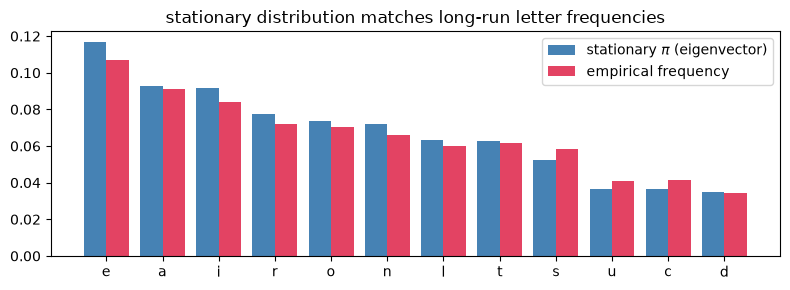

In [4]:
# stationary distribution = eigenvalue-1 left eigenvector of the transition matrix P (from section 1)
vals, vecs = np.linalg.eig(P.T)
stat = np.real(vecs[:, np.argmin(np.abs(vals - 1))]); stat = np.abs(stat) / np.abs(stat).sum()

emp = np.zeros(K)                                            # empirical letter frequency in the corpus
for s in seqs:
    for ch in s:
        emp[idx[ch]] += 1
emp /= emp.sum()
order = np.argsort(-stat)[:12]
fig, ax = plt.subplots(figsize=(8, 3))
xs = np.arange(len(order)); w = 0.4
ax.bar(xs - w / 2, stat[order], w, color='steelblue', label='stationary $\\pi$ (eigenvector)')
ax.bar(xs + w / 2, emp[order], w, color='crimson', alpha=0.8, label='empirical frequency')
ax.set_xticks(xs); ax.set_xticklabels([alphabet[i] for i in order]); ax.legend()
ax.set_title('stationary distribution matches long-run letter frequencies')
plt.tight_layout(); plt.show()

## Choose the Markov order by held-out perplexity

How far back should the chain look? A higher order captures more structure but needs exponentially more data and overfits. The principled choice compares held-out perplexity (the exponentiated cross-entropy, $\exp(-\frac1N\sum\log p)$ - lower is better) across orders on data the model never saw. We sweep orders 0-3 with add-$\alpha$ smoothing and read off where perplexity stops improving.


In [5]:
from collections import defaultdict
ntr = int(0.8 * len(seqs)); tr_seqs, te_seqs = seqs[:ntr], seqs[ntr:]
def perplexity(order, alpha=0.3):
    ctx = defaultdict(lambda: defaultdict(float)); vocab_ = set()
    for s in tr_seqs:
        ss = ['^'] * order + list(s) + ['$']
        for t in range(order, len(ss)):
            ctx[tuple(ss[t - order:t])][ss[t]] += 1; vocab_.add(ss[t])
    Vn = len(vocab_); tot, n = 0.0, 0
    for s in te_seqs:
        ss = ['^'] * order + list(s) + ['$']
        for t in range(order, len(ss)):
            d = ctx.get(tuple(ss[t - order:t]), {})
            p = (d.get(ss[t], 0.0) + alpha) / (sum(d.values()) + alpha * Vn)
            tot += np.log(p); n += 1
    return np.exp(-tot / n)
for order in [0, 1, 2, 3]:
    print('order %d (%d-gram)  held-out perplexity = %.2f' % (order, order + 1, perplexity(order)))
print('perplexity falls then flattens/rises: the lowest point is the order the data can support.')

order 0 (1-gram)  held-out perplexity = 19.34
order 1 (2-gram)  held-out perplexity = 13.38
order 2 (3-gram)  held-out perplexity = 11.07
order 3 (4-gram)  held-out perplexity = 11.64
perplexity falls then flattens/rises: the lowest point is the order the data can support.


## Illustration: spectral gap and a periodic counterexample

We track the total-variation distance to the stationary distribution as the power iteration proceeds. For
an aperiodic chain it decays geometrically at the rate set by the second eigenvalue; for the
always-switching periodic chain it never settles, oscillating instead, exactly as the theorem warns.

In [6]:
rng = np.random.RandomState(0)
def stationary(P):
    w, v = np.linalg.eig(P.T); i = np.argmin(np.abs(w - 1)); p = np.real(v[:, i]); return p / p.sum()
P = np.array([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1], [0.2, 0.3, 0.5]])     # aperiodic, irreducible
pi = stationary(P); lam2 = sorted(np.abs(np.linalg.eigvals(P)))[-2]
d = np.array([1.0, 0.0, 0.0]); tv = []
for _ in range(30):
    tv.append(0.5 * np.abs(d - pi).sum()); d = d @ P
print('second-eigenvalue modulus |lambda_2| = %.3f' % lam2)
print('TV distance at steps 5, 10, 20 = %.4f, %.4f, %.4f (geometric, ratio ~ |lambda_2|)' %
      (tv[5], tv[10], tv[20]))
Pper = np.array([[0.0, 1.0], [1.0, 0.0]]); dp = np.array([1.0, 0.0]); osc = []
for _ in range(8):
    osc.append(dp.copy()); dp = dp @ Pper
print('periodic chain distribution over steps:', [tuple(np.round(o, 1)) for o in osc[:6]])
print('it oscillates between (1,0) and (0,1) forever: no convergence despite a unique stationary (0.5,0.5).')

second-eigenvalue modulus |lambda_2| = 0.600
TV distance at steps 5, 10, 20 = 0.0495, 0.0038, 0.0000 (geometric, ratio ~ |lambda_2|)
periodic chain distribution over steps: [(np.float64(1.0), np.float64(0.0)), (np.float64(0.0), np.float64(1.0)), (np.float64(1.0), np.float64(0.0)), (np.float64(0.0), np.float64(1.0)), (np.float64(1.0), np.float64(0.0)), (np.float64(0.0), np.float64(1.0))]
it oscillates between (1,0) and (0,1) forever: no convergence despite a unique stationary (0.5,0.5).


## References

- Shannon, C. E. (1948). A mathematical theory of communication (https://doi.org/10.1002/j.1538-7305.1948.tb01338.x). Bell System Tech. J. 27, 379-423, 623-656. - $n$-gram models of language and entropy rate.
- Norris, J. R. (1997). Markov Chains. Cambridge University Press.
- Levin, D. A., Peres, Y. & Wilmer, E. L. (2017). Markov Chains and Mixing Times (https://pages.uoregon.edu/dlevin/MARKOV/), 2nd ed. AMS. - mixing time and the spectral gap.
- Brin, S. & Page, L. (1998). The anatomy of a large-scale hypertextual web search engine (https://doi.org/10.1016/S0169-7552(98)00110-X). Computer Networks 30, 107-117. - PageRank as a stationary distribution.
- Jurafsky, D. & Martin, J. H. (2023). Speech and Language Processing (https://web.stanford.edu/~jurafsky/slp3/), 3rd ed. (draft). - $n$-gram language models and smoothing.


## Exercises and extensions

1. Higher-order models and smoothing. Build order-0/1/2/3 character (or word) models, score held-out text in bits per symbol (cross-entropy), and implement at least one principled smoothing scheme (add-$k$, then Kneser-Ney; Jurafsky & Martin). Plot bits/symbol vs order and identify where more context stops paying off given the data.
2. Mixing time and the spectral gap. Compute the transition matrix's second eigenvalue and relate it to the empirical mixing time (steps until the distribution is within $\epsilon$ of stationary), reproducing the spectral-gap bound (Levin-Peres-Wilmer).
3. PageRank on a real graph. Build the Google matrix (with teleportation) on a real directed graph and compute its stationary distribution by power iteration; relate convergence speed to the damping factor and the spectral gap (Brin & Page).
4. Generation and evaluation. Sample sequences from each model order and evaluate quality both intrinsically (held-out perplexity) and by a simple human/heuristic plausibility score; discuss the gap between the two.
